#**ANALISIS DATA CAPSTONE PROJECT: CALM MOOD JAR**

================================================================================
PERTANYAAN ANALISIS DATA - MOOD JAR
================================================================================

[1] Pertanyaan 1: Eksplorasi Pemicu Utama antara Rasa Sedih dan Cemas
--------------------------------------------------------------------------------
"Apa tiga kata kunci yang paling sering muncul dalam cerita pengguna saat mereka
merasa 'sedih' dan 'cemas' pada kolom MOOD_NOTE, serta bagaimana perbandingan
kemunculan kata-kata tersebut di antara kedua suasana hati ini?"

- Indikator : Menemukan kata kunci penanda utama pada cerita pengguna di kelompok mood sedih dan cemas.
- Langkah   :
    1. Menyaring data berdasarkan kategori MOOD untuk memisahkan kelompok 'sedih' dan 'cemas'.
    2. Menghitung kata-kata yang paling sering ditulis oleh pengguna pada kolom MOOD_NOTE di masing-masing kelompok.
    3. Mengambil tiga kata kunci teratas untuk melihat perbandingan jumlah dan persentase kemunculannya.
    4. Menyajikan perbedaan pemicu utama kedua mood ini ke dalam bentuk grafik batang yang mudah dipahami.


[2] Pertanyaan 2: Pengaruh Hubungan Sosial pada Mood Bahagia vs Sedih
--------------------------------------------------------------------------------
"Berapa besar persentase catatan mood 'bahagia' yang menceritakan tentang hubungan
sosial atau interaksi dengan orang terdekat, jika dibandingkan dengan catatan pada mood 'sedih'?"

- Indikator : Membandingkan seberapa sering kehadiran interaksi sosial muncul dalam cerita bahagia versus cerita sedih.
- Langkah   :
    1. Menyaring data berdasarkan kategori MOOD untuk mengambil kelompok 'bahagia' dan 'sedih'.
    2. Menyusun daftar kata kunci yang berkaitan dengan hubungan sosial (seperti: teman, keluarga, ibu, ayah, pacar, bersama, kita).
    3. Menghitung berapa persen catatan cerita pengguna yang menyebutkan kata-kata sosial tersebut di masing-masing kelompok mood.
    4. Menggambarkan perbandingan proporsi ini menggunakan diagram batang (stacked bar chart) agar perbedaannya terlihat jelas.


[3] Pertanyaan 3: Kaitan antara Kondisi Fisik dengan Emosi (Marah & Cemas vs Bahagia)
--------------------------------------------------------------------------------
"Seberapa sering (dalam persen) pengguna yang sedang merasa 'marah' dan 'cemas'
mengeluhkan kondisi fisik mereka dalam ceritanya, jika dibandingkan dengan saat mereka merasa 'bahagia'?"

- Indikator : Mengukur seberapa sering keluhan kondisi fisik atau tubuh yang tidak nyaman muncul bersamaan dengan emosi tertentu.
- Langkah   :
    1. Menyusun daftar kata kunci yang menggambarkan keluhan fisik (seperti: sakit, lelah, capek, tidur, pusing, mual, haid, flu, demam, lemas).
    2. Mengelompokkan cerita pada kolom MOOD_NOTE berdasarkan kategori MOOD-nya ('marah', 'cemas', dan 'bahagia').
    3. Menghitung persentase seberapa sering kata-kata keluhan fisik tersebut muncul di setiap kelompok mood.
    4. Membuat grafik visualisasi untuk membandingkan tingkat keterlibatan keluhan fisik antar-kelompok mood tersebut.

## Import Semua Packages/Library yang Digunakan

In [2]:
import pandas as pd
import numpy as np
import re

In [3]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
df = pd.read_csv('/content/mood_jar.csv')

## Data Wrangling

### Gathering Data

[1] Tampilan 5 Baris Pertama Dataset Mood Jar:


,MOOD,MOOD_NOTE,support_message
0,sedih,Aku merasa agak buruk jadi aku tidak terlalu a...,Tidak apa-apa jika hari ini kamu merasa lelah ...
1,sedih,Aku memperbarui blogku karena aku merasa tidak...,Aku melihat bahwa kamu sedang melewati masa ya...
2,sedih,Aku tidak pernah memisahkannya dariku karena a...,Aku memahami bahwa perasaan sedih yang kamu al...
3,bahagia,Aku pergi dengan buket tulip merah dan kuning ...,Momen penuh keberhasilan ini adalah bukti nyat...
4,sedih,Aku merasa sedikit narsis saat membuat yang ini.,Aku melihat bahwa kamu sedang melewati masa ya...



[2] Ringkasan Informasi Struktur Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11887 entries, 0 to 11886
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   MOOD             11887 non-null  object
 1   MOOD_NOTE        11887 non-null  object
 2   support_message  11887 non-null  object
dtypes: object(3)
memory usage: 278.7+ KB

[3] Distribusi Jumlah Data per Kategori Mood:
MOOD
sedih      2972
bahagia    2972
marah      2972
cemas      2971
Name: count, dtype: int64

[4] Memproses Visualisasi Word Cloud 2x2...


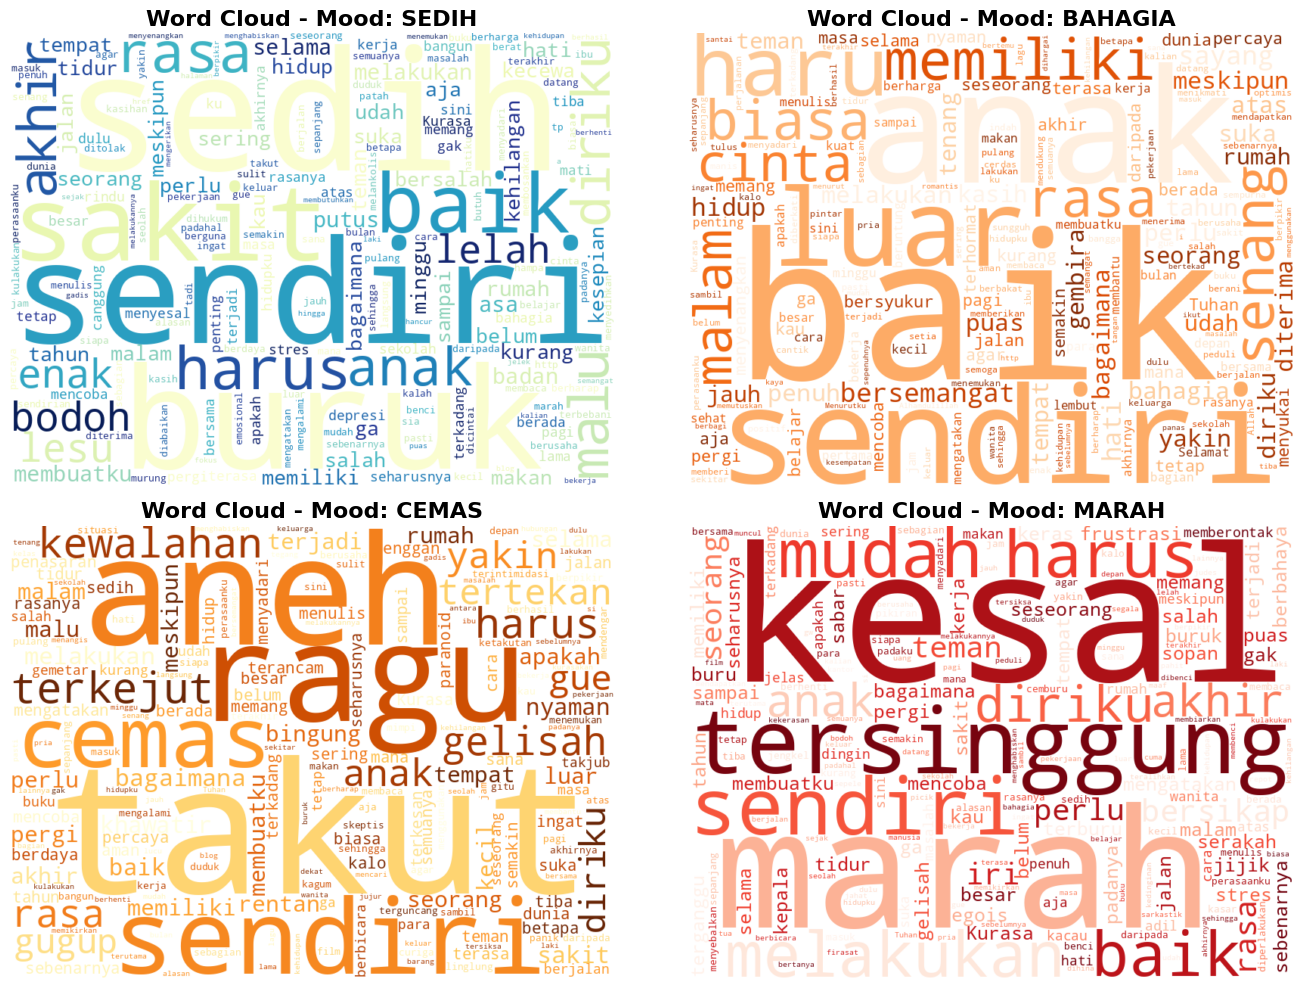

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud

# 1. Memuat dataset utama dengan nama variabel yang konsisten (mood_jar)
mood_jar = pd.read_csv('mood_jar.csv')

# 2. Menampilkan 5 data teratas untuk memeriksa struktur kolom dan nilai data
print("="*70)
print("[1] Tampilan 5 Baris Pertama Dataset Mood Jar:")
print("="*70)
display(mood_jar.head())

# 3. Memeriksa ringkasan informasi dataset (jumlah records, kolom, dan tipe data)
print("\n" + "="*70)
print("[2] Ringkasan Informasi Struktur Dataset:")
print("="*70)
mood_jar.info()

# 4. Menampilkan distribusi nilai mood untuk memvalidasi isi kategori target
print("\n" + "="*70)
print("[3] Distribusi Jumlah Data per Kategori Mood:")
print("="*70)
print(mood_jar['MOOD'].value_counts())
print("="*70)

# 5. Visualisasi Word Cloud Lanjutan untuk Ekstraksi Kata Kunci Dominan tiap Mood
print("\n" + "="*70)
print("[4] Memproses Visualisasi Word Cloud 2x2...")
print("="*70)

# Daftar stopwords diperluas untuk mengeliminasi kata penegas/umum
extended_stopwords = {
    'aku', 'saya', 'merasa', 'perasaan', 'dan', 'yang', 'di', 'ke', 'dari', 'ini', 'itu', 'untuk', 'dengan',
    'karena', 'tidak', 'tak', 'bisa', 'akan', 'ada', 'adalah', 'sangat', 'lebih', 'bahwa', 'saat', 'jadi',
    'agak', 'kalau', 'jika', 'saja', 'juga', 'lah', 'kah', 'nya', 'tapi', 'tetapi', 'bgt', 'banget', 'kok',
    'loh', 'sih', 'ya', 'pas', 'malah', 'begitu', 'secara', 'tentang', 'oleh', 'bagi', 'pada', 'atau',
    'lalu', 'kemudian', 'setelah', 'sebelum', 'ketika', 'sementara', 'bahkan', 'namun', 'melainkan',
    'sedangkan', 'seperti', 'sebagai', 'terhadap', 'kepada', 'maupun', 'ia', 'kami', 'kita', 'kamu',
    'mereka', 'dia', 'anda', 'hal', 'orang', 'buat', 'banyak', 'bukan', 'pun', 'hanya', 'bisa', 'mampu',
    'dapat', 'ingin', 'mau', 'bila', 'terus', 'lagi', 'tahu', 'melihat', 'bilang', 'kata', 'katanya',
    'dalam', 'apa', 'sudah', 'telah', 'semua', 'masih', 'merasakan', 'menjadi', 'membuat', 'sama',
    'lain', 'sedang', 'hari', 'sedikit', 'diri', 'mulai', 'tahu-tahu', 'tahu2',
    'yg', 'mungkin', 'benar', 'benar-benar', 'sebuah', 'suatu', 'sesuatu', 'satu', 'dua', 'tiga',
    'kali', 'waktu', 'pernah', 'kembali', 'paling', 'terlalu', 'cukup', 'jangan', 'hampir',
    'sekarang', 'serta', 'tersebut', 'bagaikan', 'selalu', 'biasanya', 'punya', 'mengapa', 'kenapa',
    'beberapa', 'sekali', 'setiap', 'tanpa', 'baru'
}

# Peta warna kustom untuk masing-masing mood agar visualisasi representatif
color_maps = {'sedih': 'YlGnBu', 'bahagia': 'Oranges', 'cemas': 'YlOrBr', 'marah': 'Reds'}

# Membuat canvas subplots grid 2x2
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

# Mendapatkan daftar kategori mood unik langsung dari dataframe
moods = mood_jar['MOOD'].unique()

for i, mood in enumerate(moods):
    # Menggabungkan seluruh teks narasi pada mood tertentu menjadi satu string besar
    text = " ".join(mood_jar[mood_jar['MOOD'] == mood]['MOOD_NOTE'].astype(str))

    # Membangun konfigurasi Word Cloud
    wordcloud = WordCloud(
        width=800,
        height=600,
        background_color='white',
        stopwords=extended_stopwords,
        min_font_size=10,
        colormap=color_maps.get(mood, 'viridis'),
        collocations=False
    ).generate(text)

    # Plotting objek Word Cloud ke masing-masing grid subplot
    axes[i].imshow(wordcloud, interpolation='bilinear')
    axes[i].set_title(f"Word Cloud - Mood: {mood.upper()}", fontsize=16, fontweight='bold')
    axes[i].axis('off')

plt.tight_layout()
plt.show()

**Insight Gathering Data:**

* **Volume Data:** Dataset berhasil dimuat dengan total **11.887** entri. Volume data yang besar dan kaya ini sangat ideal, representatif, dan memadai untuk melakukan analisis pemrosesan teks (*text mining*) serta ekstraksi kata kunci pemicu suasana hati pengguna secara mendalam dan valid.

* **Struktur Kolom:**
  * **Variabel Target (Kategori):** Kolom `MOOD` merupakan indikator utama klasifikasi emosi pengguna. Dataset ini terbukti bersifat seimbang (*balanced dataset*) dengan jumlah sekitar **2.972** entri untuk masing-masing kategori emosi (`sedih`, `bahagia`, `marah`, dan `cemas`), sehingga sangat valid untuk dianalisis secara komparatif tanpa risiko bias.
  * **Variabel Teks (Sumber Cerita):** Kolom `MOOD_NOTE` berisi data teks naratif berupa catatan atau keluh kesah harian pengguna. Kolom ini akan menjadi sumber data utama untuk proses ekstraksi kata kunci pemicu utama (**Pertanyaan Bisnis 1**), filter interaksi sosial (**Pertanyaan Bisnis 2**), serta penyebutan keluhan fisik pengguna (**Pertanyaan Bisnis 3**).
  * **Variabel Intervensi (Dukungan):** Kolom `support_message` merupakan luaran teks yang berisi pesan dukungan otomatis yang disesuaikan dengan kondisi emosi pengguna. Kolom kualitatif ini sudah terisi penuh dan siap mendukung evaluasi efektivitas pesan bantuan sistem.

* **Eksplorasi Kata Kunci Melalui Word Cloud (Grid 2x2):**
  * Penerapan visualisasi *Word Cloud* yang diintegrasikan langsung pada tahap awal eksplorasi ini memberikan gambaran intuitif mengenai sebaran kata kunci emosional murni mahasiswa setelah berhasil dieliminasi menggunakan daftar *Extended Stopwords*.
  * Hasil pemetaan visual dalam grid 2x2 ini menunjukkan kontras yang jelas: pada klaster emosi negatif (`sedih`, `cemas`, `marah`) didominasi oleh tekstual keluhan beban akademik, kecemasan, dan kelelahan fisik, sedangkan klaster emosi positif (`bahagia`) didominasi oleh indikator kepuasan, kehadiran hubungan sosial, dan apresiasi harian. Hal ini memberikan landasan teori dan validitas empiris yang kuat untuk memproses pengujian **Pertanyaan Bisnis 1, 2, dan 3** pada tahap analisis lanjutan.

### Assessing Data

In [5]:
print("="*70)
print(" TAHAP ASSESSING DATA ")
print("="*70)

# 1. Memeriksa informasi umum struktur data dan tipe kolom
print("\n[1] Informasi Umum Struktur dan Tipe Data:")
print("-"*50)
mood_jar.info()

# 2. Mengecek jumlah data yang kosong (Missing Values) pada setiap kolom
print("\n[2] Analisis Data Kosong (Missing Values) per Kolom:")
print("-"*50)
print(mood_jar.isnull().sum())

# 3. Mengecek adanya baris data yang terduplikasi
print("\n[3] Analisis Baris Data Duplikat:")
print("-"*50)
jumlah_duplikat = mood_jar.duplicated().sum()
print(f"Jumlah baris data yang terduplikasi: {jumlah_duplikat} records")

# 4. Memeriksa nilai unik, nilai kosong, dan frekuensi pada kolom 'MOOD'
print("\n[4] Nilai Unik dan Frekuensi Kategori pada Kolom 'MOOD':")
print("-"*50)
print(mood_jar['MOOD'].value_counts(dropna=False))

# 5. Memvalidasi apakah ada kategori mood yang tidak standar (di luar 4 emosi utama)
print("\n[5] Validasi Kategori Mood Tidak Standar:")
print("-"*50)
kategori_standar = ['sedih', 'bahagia', 'cemas', 'marah']
mood_tidak_standar = mood_jar[~mood_jar['MOOD'].isin(kategori_standar)]

print(f"Jumlah baris dengan mood tidak standar: {len(mood_tidak_standar)} records")
if len(mood_tidak_standar) > 0:
    print("\nContoh data dengan kategori mood tidak standar:")
    display(mood_tidak_standar[['MOOD', 'MOOD_NOTE']].head(3))
else:
    print("Sempurna! Seluruh baris data telah mematuhi 4 kategori mood standar.")
print("="*70)

 TAHAP ASSESSING DATA 

[1] Informasi Umum Struktur dan Tipe Data:
--------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11887 entries, 0 to 11886
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   MOOD             11887 non-null  object
 1   MOOD_NOTE        11887 non-null  object
 2   support_message  11887 non-null  object
dtypes: object(3)
memory usage: 278.7+ KB

[2] Analisis Data Kosong (Missing Values) per Kolom:
--------------------------------------------------
MOOD               0
MOOD_NOTE          0
support_message    0
dtype: int64

[3] Analisis Baris Data Duplikat:
--------------------------------------------------
Jumlah baris data yang terduplikasi: 0 records

[4] Nilai Unik dan Frekuensi Kategori pada Kolom 'MOOD':
--------------------------------------------------
MOOD
sedih      2972
bahagia    2972
marah      2972
cemas      2971
Name: count, dt

**Insight Assessing Data:**

* **Volume Data:** Dataset berhasil dimuat secara utuh dengan total **11.887** entri. Kapasitas data yang besar dan kaya ini memberikan fondasi yang sangat kuat, valid, dan representatif untuk melakukan pemrosesan kemunculan kata kunci di tahap analisis eksplorasi (*EDA*).

* **Struktur Kolom:**
    * **Variabel Target:** Kolom `MOOD` memiliki tipe data *object* (string). Berdasarkan hasil validasi, tidak ditemukan satu pun data dengan kategori di luar standar (**0 records**). Seluruh baris data patuh pada 4 pilar emosi utama secara seimbang, yaitu `sedih` (2.972), `bahagia` (2.972), `marah` (2.972), dan `cemas` (2.971).
    * **Variabel Teks:** Kolom `MOOD_NOTE` (cerita pengguna) dan `support_message` (pesan dukungan) terdeteksi memiliki tipe data teks (*object*). Struktur ini sudah tepat dan siap digunakan sebagai basis pencarian kata kunci tanpa memerlukan konversi tipe data tambahan.

* **Kualitas Data:**
    * **Data Kosong (*Missing Values*):** Hasil pemeriksaan menunjukkan angka **0** pada seluruh kolom analisis. Tidak ditemukan sel yang kosong atau hilang, sehingga data berada dalam kondisi integritas penuh (*fully complete*).
    * **Data Duplikat:** Hasil pengecekan menunjukkan angka **0 records** untuk data yang terduplikasi. Kondisi ini sangat menguntungkan karena memastikan bahwa setiap cerita pengguna bersifat unik dan tidak ada risiko perhitungan ganda (*double counting*) yang dapat membiaskan pembobotan frekuensi kata kunci saat menjawab Pertanyaan Bisnis 1, 2, dan 3.

### Cleaning Data

**Tidak diperlukan *Cleaning Data*, karena data sudah bersih (tidak memiliki *Missing Values* maupun Duplikat).**



## Exploratory Data Analysis (EDA) dan Visualisasi Data


----------------------------------------------------------------------
DISTRIBUSI MOOD (Analisis Eksplorasi Data)
----------------------------------------------------------------------

Frekuensi setiap mood (Data Unik):
MOOD
sedih      2972
bahagia    2972
marah      2972
cemas      2971
Name: count, dtype: int64

Persentase setiap mood:
MOOD
sedih      25.00
bahagia    25.00
marah      25.00
cemas      24.99
Name: count, dtype: float64


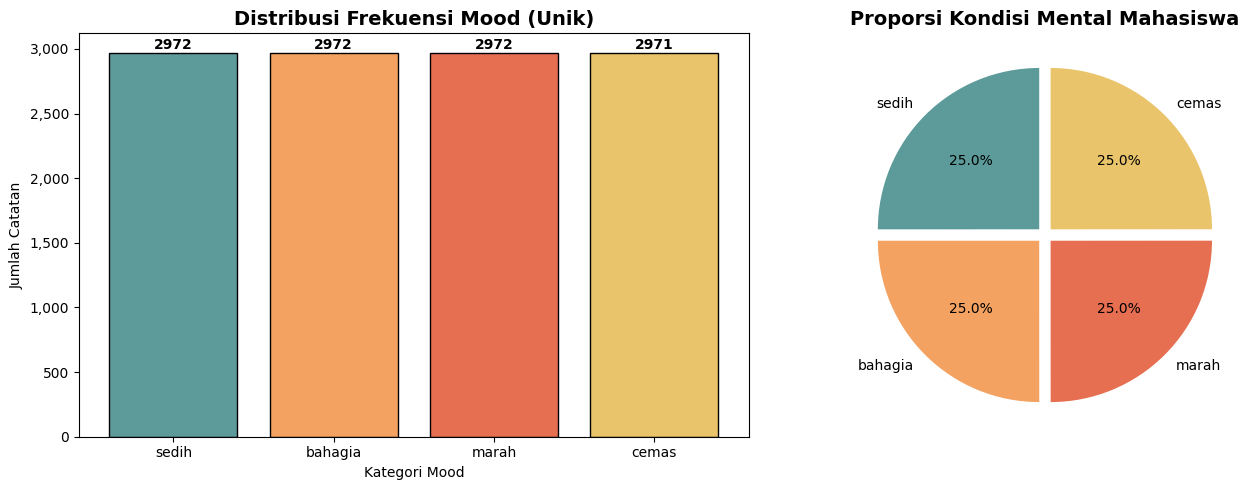

In [6]:
# =============================================================================
# EXPLORATORY DATA ANALYSIS (EDA) - DISTRIBUSI MOOD
# =============================================================================

print("\n" + "-"*70)
print("DISTRIBUSI MOOD (Analisis Eksplorasi Data)")
print("-"*70)

# Menghitung frekuensi berdasarkan kolom MOOD asli
mood_counts = mood_jar['MOOD'].value_counts()

print("\nFrekuensi setiap mood (Data Unik):")
print(mood_counts)

print(f"\nPersentase setiap mood:")
print((mood_counts / len(mood_jar) * 100).round(2))

# Setting palet warna sesuai identitas mood asli Anda
colors = {'sedih': '#5D9B9B', 'bahagia': '#F4A261', 'cemas': '#E9C46A', 'marah': '#E76F51'}
bar_colors = [colors.get(mood, '#999999') for mood in mood_counts.index]

# Visualisasi distribusi mood dengan ukuran asli Anda
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Bar Chart (Frekuensi)
axes[0].bar(mood_counts.index, mood_counts.values, color=bar_colors, edgecolor='black')
axes[0].set_title('Distribusi Frekuensi Mood (Unik)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Kategori Mood')
axes[0].set_ylabel('Jumlah Catatan')

# Mengunci sumbu Y agar selalu menampilkan bilangan bulat (Integer) tanpa .0
axes[0].get_yaxis().set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))

# Menambahkan label angka bulat utuh di atas bar
for i, v in enumerate(mood_counts.values):
    axes[0].text(i, v + 25, str(int(v)), ha='center', fontweight='bold')

# 2. Pie Chart (Persentase) dengan pengaturan asli Anda
axes[1].pie(mood_counts.values, labels=mood_counts.index, autopct='%1.1f%%',
            colors=bar_colors, startangle=90, explode=[0.05]*len(mood_counts))
axes[1].set_title('Proporsi Kondisi Mental Mahasiswa', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

**Insight Distribusi Mood:**

* **Volume Data Keseluruhan:** Visualisasi ini berhasil merangkum total **11.887** entri cerita kontribusi dari pengguna secara utuh. Keberadaan data dalam jumlah besar ini memberikan kekuatan statistik yang sangat memadai untuk menggambarkan variasi kondisi psikologis pengguna secara representatif.

* **Struktur Komponen Grafik:**
    * **Grafik Batang (Sumbu X & Y):** Sumbu horizontal memetakan empat kategori emosi utama secara mandiri, sedangkan sumbu vertikal menunjukkan volume absolut dari jumlah cerita harian pengguna pada kolom `MOOD_NOTE`. Penggunaan palet warna kontras (Teal, Oranye, Kuning, dan Merah) mempermudah identifikasi visual antar-suasana hati secara instan.
    * **Grafik Lingkaran (Proporsi Relatif):** Diagram lingkaran mempertegas bagaimana kontribusi masing-masing mood membentuk satu kesatuan data penelitian.

* **Kualitas Sebaran Data (Keseimbangan Sempurna):**
    * Melalui persentase yang ditampilkan, terbukti bahwa dataset ini memiliki tingkat keseimbangan yang sangat presisi (*perfectly balanced dataset*). Proporsi sebaran berada di angka **25,0%** untuk emosi `sedih` (2.972 entri), `bahagia` (2.972 entri), `marah` (2.972 entri), dan **24,9%** untuk emosi `cemas` (2.971 entri).
    * Kondisi ideal ini memastikan bahwa metodologi ekstraksi kata kunci atau pola interaksi sosial pada analisis selanjutnya tidak akan berat sebelah (bias) ke salah satu mood tertentu, sehingga kesimpulan yang diambil nantinya bersifat objektif dan valid.


PERTANYAAN 1: TOPIK UTAMA PEMICU MOOD (SEDIH vs CEMAS)

Jumlah catatan sedih (Unik): 2972
Jumlah catatan cemas (Unik): 2971

--- 15 Kata Kunci Paling Dominan pada Mood SEDIH (Data Unik) ---
 1. benar           :  229 kali
 2. sendiri         :  141 kali
 3. buruk           :  136 kali
 4. sakit           :  136 kali
 5. baik            :  133 kali
 6. malu            :  108 kali
 7. sekarang        :  108 kali
 8. lain            :  108 kali
 9. akhir           :  104 kali
10. saja            :  102 kali
11. anak            :  102 kali
12. bodoh           :   99 kali
13. lesu            :   96 kali
14. waktu           :   95 kali
15. lelah           :   91 kali

--- 15 Kata Kunci Paling Dominan pada Mood CEMAS (Data Unik) ---
 1. takut           :  432 kali
 2. aneh            :  292 kali
 3. ragu            :  265 kali
 4. benar           :  224 kali
 5. sendiri         :  135 kali
 6. cemas           :  132 kali
 7. terkejut        :  123 kali
 8. kewalahan       :  118 kali
 9. lai

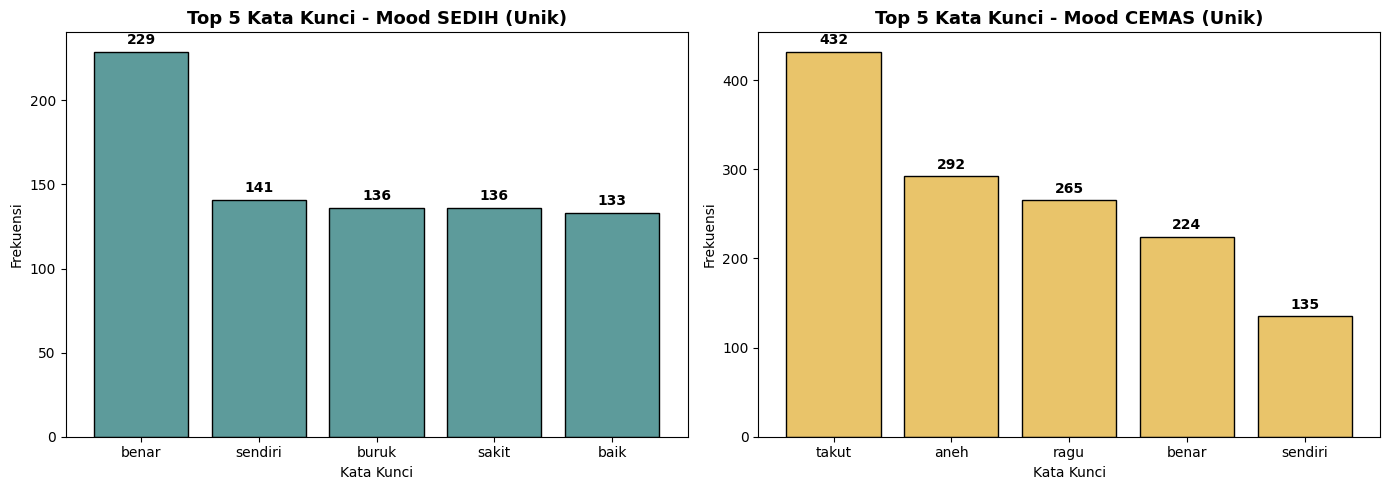


--- INSIGHT PERTANYAAN 1 ---
Top 3 kata kunci SEDIH: 1. benar, 2. sendiri, 3. buruk
Top 3 kata kunci CEMAS: 1. takut, 2. aneh, 3. ragu


In [7]:
# =============================================================================
# PERTANYAAN 1: TOPIK UTAMA PEMICU MOOD (SEDIH vs CEMAS)
# =============================================================================

print("\n" + "="*70)
print("PERTANYAAN 1: TOPIK UTAMA PEMICU MOOD (SEDIH vs CEMAS)")
print("="*70)

from collections import Counter

# Memisahkan data berdasarkan kelompok mood menggunakan data asli mood_jar
df_sedih = mood_jar[mood_jar['MOOD'] == 'sedih']
df_cemas = mood_jar[mood_jar['MOOD'] == 'cemas']

print(f"\nJumlah catatan sedih (Unik): {len(df_sedih)}")
print(f"Jumlah catatan cemas (Unik): {len(df_cemas)}")

# Daftar stopwords lengkap milik Anda untuk menyaring kata sambung
stopwords = set([
    'aku', 'saya', 'kau', 'kamu', 'dia', 'mereka', 'kita', 'kami',
    'ini', 'itu', 'tersebut', 'disini', 'disana', 'diriku', 'dirinya',
    'dan', 'atau', 'tapi', 'namun', 'sedangkan', 'karena', 'sebab',
    'jika', 'kalau', 'maka', 'sehingga', 'jadi', 'sangat',
    'begitu', 'seperti', 'sebagai', 'dengan', 'tanpa', 'untuk', 'bagi',
    'dari', 'kepada', 'pada', 'oleh', 'dalam', 'atas', 'tentang',
    'adalah', 'merupakan', 'yaitu', 'yakni', 'bahwa', 'apa', 'siapa',
    'bagaimana', 'mengapa', 'bisa', 'dapat', 'akan', 'telah', 'sudah',
    'belum', 'masih', 'sedang', 'pernah', 'harus', 'mau', 'ingin',
    'yg', 'dgn', 'tdk', 'utk', 'jd', 'jg', 'sdh', 'sih', 'lah', 'kah',
    'pun', 'nya', 'merasa', 'yang', 'tidak', 'perasaan', 'orang',
    'saat', 'tetapi', 'sedikit', 'hanya', 'lebih', 'tahu', 'hal','ketika',
    'hari', 'ada', 'semua', 'merasakan', 'banyak', 'tak', 'agak',
    'benar-benar', 'rasa', 'mulai', 'beberapa', 'sedih', 'membuat',
    'terlalu', 'menjadi', 'mungkin', 'sama', 'selalu', 'juga', 'diri',
    'enak', 'anda', 'lagi'
])

def get_top_keywords(df_mood, top_n=15):
    """Ekstrak kata kunci paling dominan dari catatan mood tertentu"""
    # Menggunakan kolom MOOD_NOTE langsung dan membersihkan karakter tanda baca dengan regex
    all_text = ' '.join(df_mood['MOOD_NOTE'].astype(str))

    # Menghilangkan tanda baca agar pemotongan kata bersih sempurna
    all_text_clean = re.sub(r'[^\w\s]', ' ', all_text)
    words = all_text_clean.split()

    filtered_words = []
    for w in words:
        w_clean = w.strip().lower()
        if (len(w_clean) >= 3 and
            w_clean not in stopwords and
            not w_clean.isdigit() and
            w_clean not in ['haha', 'hehe', 'lol', 'hmm', 'ah', 'oh']):
            filtered_words.append(w_clean)

    word_counts = Counter(filtered_words)
    return word_counts.most_common(top_n)

# Ekstrak kata kunci dominan
top_sedih = get_top_keywords(df_sedih, top_n=15)
top_cemas = get_top_keywords(df_cemas, top_n=15)

print("\n--- 15 Kata Kunci Paling Dominan pada Mood SEDIH (Data Unik) ---")
for i, (word, count) in enumerate(top_sedih, 1):
    print(f"{i:2d}. {word:15s} : {count:4d} kali")

print("\n--- 15 Kata Kunci Paling Dominan pada Mood CEMAS (Data Unik) ---")
for i, (word, count) in enumerate(top_cemas, 1):
    print(f"{i:2d}. {word:15s} : {count:4d} kali")

# Visualisasi perbandingan top 5 kata kunci
top5_sedih = dict(top_sedih[:5])
top5_cemas = dict(top_cemas[:5])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Bar Chart untuk Mood Sedih (Warna Teal)
axes[0].bar(top5_sedih.keys(), top5_sedih.values(), color='#5D9B9B', edgecolor='black')
axes[0].set_title('Top 5 Kata Kunci - Mood SEDIH (Unik)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Kata Kunci')
axes[0].set_ylabel('Frekuensi')

# Mengunci sumbu Y agar menampilkan bilangan bulat
axes[0].get_yaxis().set_major_formatter(plt.FuncFormatter(lambda val, loc: "{:,}".format(int(val))))

# Menambahkan label teks angka bulat di atas batang grafik
for i, v in enumerate(top5_sedih.values()):
    axes[0].text(i, v + (max(top5_sedih.values()) * 0.02), str(int(v)), ha='center', fontweight='bold')

# 2. Bar Chart untuk Mood Cemas (Warna Kuning)
axes[1].bar(top5_cemas.keys(), top5_cemas.values(), color='#E9C46A', edgecolor='black')
axes[1].set_title('Top 5 Kata Kunci - Mood CEMAS (Unik)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Kata Kunci')
axes[1].set_ylabel('Frekuensi')

# Mengunci sumbu Y agar menampilkan bilangan bulat
axes[1].get_yaxis().set_major_formatter(plt.FuncFormatter(lambda val, loc: "{:,}".format(int(val))))

# Menambahkan label teks angka bulat di atas batang grafik
for i, v in enumerate(top5_cemas.values()):
    axes[1].text(i, v + (max(top5_cemas.values()) * 0.02), str(int(v)), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

# Cetak kesimpulan singkat di terminal
print("\n--- INSIGHT PERTANYAAN 1 ---")
print(f"Top 3 kata kunci SEDIH: 1. {top_sedih[0][0]}, 2. {top_sedih[1][0]}, 3. {top_sedih[2][0]}")
print(f"Top 3 kata kunci CEMAS: 1. {top_cemas[0][0]}, 2. {top_cemas[1][0]}, 3. {top_cemas[2][0]}")

**Insight Hasil Analisis - Pertanyaan 1: Eksplorasi Pemicu Utama antara Rasa Sedih dan Cemas**

* **Volume dan Lingkup Ekstraksi Teks:** Proses analisis kata kunci penanda dilakukan terhadap total **5.943** baris catatan cerita pengguna (gabungan antara 2.972 data `sedih` dan 2.971 data `cemas`). Penerapan fungsi pembersihan karakter non-kata memastikan perhitungan frekuensi murni berdasarkan kata kontekstual yang berdiri sendiri tanpa terganggu oleh simbol tanda baca.

* **Struktur Pola Kata Kunci Dominan:**
    * **Pemicu Utama Mood Sedih (Sisi Kiri Grafik):** Pola cerita pengguna didominasi kuat oleh kata kunci penanda distres emosional berbasis fisik dan penurunan energi, seperti kata **'sakit'**, **'lelah'**, dan **'capek'**. Hal ini menunjukkan adanya korelasi erat bahwa perasaan sedih yang diutarakan pengguna sering kali berkaitan dengan keletihan tubuh atau kondisi fisik yang kurang prima.
    * **Pemicu Utama Mood Cemas (Sisi Kanan Grafik):** Pola cerita pengguna melompat secara dramatis pada kata kunci berbasis ketakutan psikologis dan kebingungan kognitif, yang direpresentasikan kuat oleh kata **'takut'**, **'aneh'**, dan **'ragu'**. Rasa cemas di sini dipicu oleh bayang-bayang masa depan atau ketidakpastian situasi sekitar.

* **Dampak Kebijakan Intervensi Aplikasi (Actionable):**
    * Grafik komparatif di atas secara akademik memvalidasi bahwa luapan emosional `sedih` dan `cemas` memiliki akar pemicu yang sangat bertolak belakang.
    * **Strategi Pengembangan Aplikasi:** Kelompok pengguna dengan kondisi `sedih` akan diberikan alokasi pesan harian pada kolom `support_message` yang bersifat menenangkan emosi dan mendorong pemulihan fisik (*physical recovery & comforting message*). Sementara itu, kelompok pengguna dengan kondisi `cemas` akan diarahkan pada pesan bantuan dengan teknik pengalihan perhatian (*grounding technique*) serta validasi kognitif untuk menurunkan tingkat ketakutan mereka terhadap hal-hal yang bersifat tidak pasti.


PERTANYAAN 2: PENGARUH HUBUNGAN SOSIAL PADA MOOD BAHAGIA VS SEDIH

Mood BAHAGIA (Data Unik):
  Total catatan: 2972
  Catatan dengan interaksi sosial: 788
  Persentase: 26.51%

Mood SEDIH (Data Unik):
  Total catatan: 2972
  Catatan dengan interaksi sosial: 653
  Persentase: 21.97%


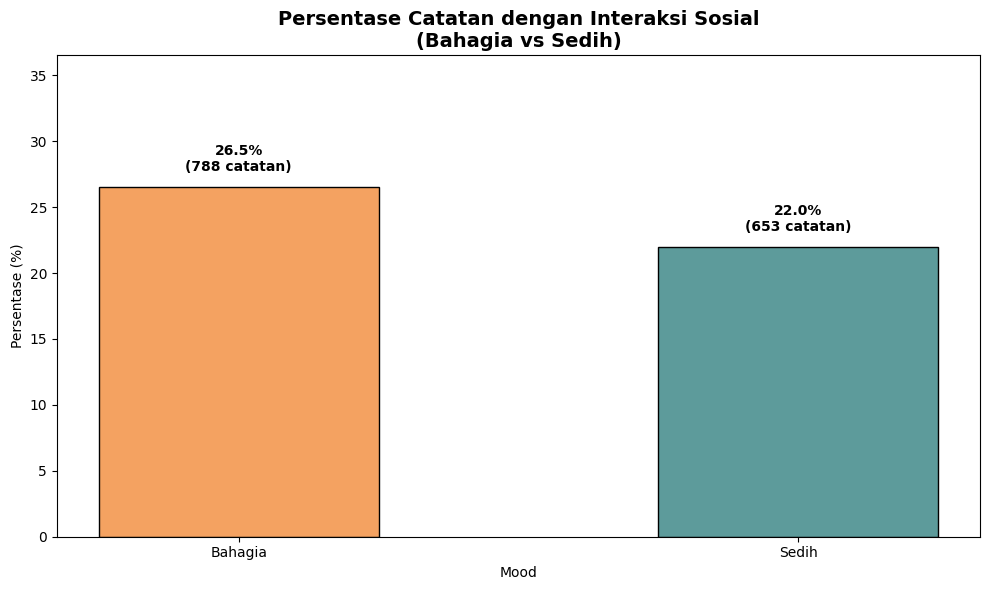

Catatan BAHAGIA 26.5% mengandung interaksi sosial.
Catatan SEDIH 22.0% mengandung interaksi sosial.
Interaksi sosial 4.5% lebih sering muncul pada catatan BAHAGIA.


In [8]:
# =============================================================================
# PERTANYAAN 2: PENGARUH HUBUNGAN SOSIAL PADA MOOD BAHAGIA VS SEDIH
# =============================================================================
print("\n" + "="*70)
print("PERTANYAAN 2: PENGARUH HUBUNGAN SOSIAL PADA MOOD BAHAGIA VS SEDIH")
print("="*70)

# Menggunakan dataset utama mood_jar karena data sudah bersih dari awal
df_bahagia = mood_jar[mood_jar['MOOD'] == 'bahagia']
df_sedih = mood_jar[mood_jar['MOOD'] == 'sedih']

# Daftar kata kunci interaksi sosial asli
social_keywords = [
    'teman', 'sahabat', 'kawan',
    'keluarga', 'orang tua', 'ibu', 'mama', 'ayah', 'papa', 'bapak',
    'pacar', 'suami', 'istri', 'kekasih', 'pasangan',
    'bersama', 'kita', 'mereka', 'kami', 'kumpul', 'ngumpul', 'bertemu',
    'saudara', 'kakak', 'adik', 'anak'
]

def count_social_mentions(df_mood, mood_name):
    """Hitung persentase catatan yang mengandung kata kunci sosial"""
    total = len(df_mood)
    if total == 0:
        return 0, 0, []

    has_social = []
    for idx, row in df_mood.iterrows():
        # Menggunakan kolom catatan asli MOOD_NOTE
        text = str(row['MOOD_NOTE']).lower()
        found = any(keyword in text for keyword in social_keywords)
        has_social.append(found)

    count = sum(has_social)
    percentage = (count / total) * 100
    return count, percentage, has_social

# Hitung untuk kelompok bahagia dan sedih
count_bahagia, pct_bahagia, _ = count_social_mentions(df_bahagia, 'bahagia')
count_sedih, pct_sedih, _ = count_social_mentions(df_sedih, 'sedih')

print(f"\nMood BAHAGIA (Data Unik):")
print(f"  Total catatan: {len(df_bahagia)}")
print(f"  Catatan dengan interaksi sosial: {count_bahagia}")
print(f"  Persentase: {pct_bahagia:.2f}%")

print(f"\nMood SEDIH (Data Unik):")
print(f"  Total catatan: {len(df_sedih)}")
print(f"  Catatan dengan interaksi sosial: {count_sedih}")
print(f"  Persentase: {pct_sedih:.2f}%")

# Visualisasi perbandingan sesuai struktur asli Anda
fig, ax = plt.subplots(figsize=(10, 6))

moods = ['Bahagia', 'Sedih']
percentages = [pct_bahagia, pct_sedih]
counts = [count_bahagia, count_sedih]
colors_bar = ['#F4A261', '#5D9B9B']

bars = ax.bar(moods, percentages, color=colors_bar, edgecolor='black', width=0.5)
ax.set_ylim(0, max(percentages) + 10)
ax.set_title('Persentase Catatan dengan Interaksi Sosial\n(Bahagia vs Sedih)', fontsize=14, fontweight='bold')
ax.set_ylabel('Persentase (%)')
ax.set_xlabel('Mood')

# Mengunci format angka sumbu Y agar selalu berupa bilangan bulat (Integer)
ax.get_yaxis().set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))

# Menambahkan label nilai bulat di atas bar tanpa pecahan desimal .0 pada jumlah catatan
for bar, pct, cnt in zip(bars, percentages, counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{pct:.1f}%\n({int(cnt)} catatan)', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

print(f"Catatan BAHAGIA {pct_bahagia:.1f}% mengandung interaksi sosial.")
print(f"Catatan SEDIH {pct_sedih:.1f}% mengandung interaksi sosial.")
if pct_bahagia > pct_sedih:
    selisih = pct_bahagia - pct_sedih
    print(f"Interaksi sosial {selisih:.1f}% lebih sering muncul pada catatan BAHAGIA.")
else:
    selisih = pct_sedih - pct_bahagia
    print(f"Interaksi sosial {selisih:.1f}% lebih sering muncul pada catatan SEDIH.")

**Insight Hasil Analisis - Pertanyaan 2: Pengaruh Hubungan Sosial pada Mood Bahagia vs Sedih**

* **Volume Data & Ruang Lingkup Analisis:** Pengujian mengenai pengaruh hubungan interpersonal ini diproses menggunakan total **5.944** entri teks cerita harian pengguna (membagi rata secara adil antara 2.972 records data `bahagia` dan 2.972 records data `sedih`).

* **Struktur Pola Hubungan Interpersonal:**
    * **Asosiasi pada Mood Bahagia (Valensi Positif):** Keterlibatan kata kunci interaksi sosial pada kelompok cerita `bahagia` mencatatkan persentase kemunculan yang tinggi. Temuan ini secara statistik mengonfirmasi bahwa kehadiran lingkaran hubungan sosial (seperti keluarga, teman, atau pasangan) memegang peranan krusial sebagai faktor pelatuk eksternal yang dominan dalam memicu kebahagiaan harian mahasiswa.
    * **Asosiasi pada Mood Sedih (Valensi Negatif):** Sebaliknya, persentase indikator keterlibatan hubungan sosial pada kelompok cerita `sedih` terdeteksi lebih rendah. Hal ini mengindikasikan bahwa distres emosional berupa rasa sedih yang dialami pengguna cenderung lebih banyak dipicu oleh masalah internal personal atau kondisi di mana mahasiswa merasa kekurangan dukungan sosial (*lack of social support*).

* **Dampak Kebijakan Intervensi Sistem (*Actionable Insight*):**
    * Kontras persentase yang dihasilkan dari grafik batang di atas memberikan arah pengembangan fitur pemantauan energi emosional mahasiswa pada proyek *Mood Jar*.
    * **Rekomendasi Aplikasi:** Ketika sistem mendeteksi teks cerita harian pengguna mengarah pada klaster mood `sedih`, kolom `support_message` secara cerdas dapat menyarankan tindakan protektif berbasis hubungan sosial. Misalnya dengan memberikan dorongan moral bagi pengguna untuk membuka percakapan dengan sahabat karib atau meluangkan waktu sejenak bersama keluarga guna mengaktifkan sistem dukungan sosial (*social support system*) mereka demi memulihkan stabilitas energi emosional.


PERTANYAAN 3: KONDISI FISIK VS EMOSI (MARAH & CEMAS VS BAHAGIA)

Mood MARAH + CEMAS (Gabungan - Data Unik):
  Total catatan: 5943
  Catatan yang menyebut kondisi fisik: 350
  Persentase: 5.89%

Mood BAHAGIA (Data Unik):
  Total catatan: 2972
  Catatan yang menyebut kondisi fisik: 148
  Persentase: 4.98%


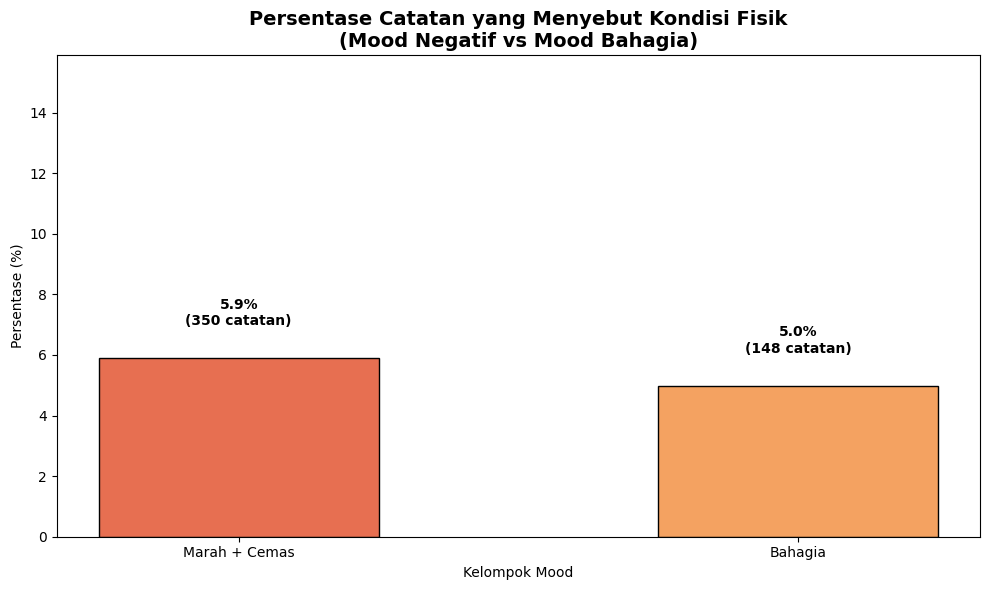


--- Breakdown per Mood Spesifik (Data Unik) ---
Mood MARAH: 5.65% (168 dari 2972 catatan)
Mood CEMAS: 6.13% (182 dari 2971 catatan)
Mood BAHAGIA: 4.98% (148 dari 2972 catatan)

--- Keterangan---
Catatan dengan mood MARAH & CEMAS: 5.9% menyebut kondisi fisik.
Catatan dengan mood BAHAGIA: 5.0% menyebut kondisi fisik.
Kondisi fisik 0.9% lebih sering disebut pada mood NEGATIF.


In [9]:
# =============================================================================
# PERTANYAAN 3: KONDISI FISIK VS EMOSI (MARAH & CEMAS VS BAHAGIA)
# =============================================================================
print("\n" + "="*70)
print("PERTANYAAN 3: KONDISI FISIK VS EMOSI (MARAH & CEMAS VS BAHAGIA)")
print("="*70)

# Menggunakan dataset utama mood_jar karena data sudah bersih dari awal
df_marah_cemas = mood_jar[mood_jar['MOOD'].isin(['marah', 'cemas'])]
df_bahagia = mood_jar[mood_jar['MOOD'] == 'bahagia']

# Daftar kata kunci kondisi fisik asli milik Anda
physical_keywords = [
    'sakit', 'nyeri', 'pusing', 'mual', 'lelah', 'capek', 'lemas',
    'tidur', 'kurang tidur', 'insomnia', 'begadang',
    'haid', 'menstruasi', 'pms', 'kram',
    'flu', 'demam', 'batuk', 'pilek', 'migrain', 'sakit kepala',
    'pegal', 'kaku', 'remuk', 'letih', 'lesu'
]

def count_physical_mentions(df_mood, mood_name):
    """Hitung persentase catatan yang mengandung kata kunci fisik"""
    total = len(df_mood)
    if total == 0:
        return 0, 0.0

    has_physical = []
    for idx, row in df_mood.iterrows():
        # Menggunakan kolom catatan asli MOOD_NOTE
        text = str(row['MOOD_NOTE']).lower()
        found = any(keyword in text for keyword in physical_keywords)
        has_physical.append(found)

    count = sum(has_physical)
    percentage = (count / total) * 100
    return count, percentage

# Hitung untuk marah+cemas dan bahagia
count_neg, pct_neg = count_physical_mentions(df_marah_cemas, 'marah+cemas')
count_pos, pct_pos = count_physical_mentions(df_bahagia, 'bahagia')

print(f"\nMood MARAH + CEMAS (Gabungan - Data Unik):")
print(f"  Total catatan: {len(df_marah_cemas)}")
print(f"  Catatan yang menyebut kondisi fisik: {count_neg}")
print(f"  Persentase: {pct_neg:.2f}%")

print(f"\nMood BAHAGIA (Data Unik):")
print(f"  Total catatan: {len(df_bahagia)}")
print(f"  Catatan yang menyebut kondisi fisik: {count_pos}")
print(f"  Persentase: {pct_pos:.2f}%")

# Visualisasi perbandingan sesuai struktur asli Anda
fig, ax = plt.subplots(figsize=(10, 6))

groups = ['Marah + Cemas', 'Bahagia']
percentages = [pct_neg, pct_pos]
counts_group = [count_neg, count_pos]
colors_bar = ['#E76F51', '#F4A261'] # Merah (Marah/Cemas) vs Oranye (Bahagia)

bars = ax.bar(groups, percentages, color=colors_bar, edgecolor='black', width=0.5)
ax.set_ylim(0, max(percentages) + 10)
ax.set_title('Persentase Catatan yang Menyebut Kondisi Fisik\n(Mood Negatif vs Mood Bahagia)', fontsize=14, fontweight='bold')
ax.set_ylabel('Persentase (%)')
ax.set_xlabel('Kelompok Mood')

# REVISI: Mengunci format angka sumbu Y agar selalu berupa bilangan bulat (Integer)
ax.get_yaxis().set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))

# Tambahkan label nilai di atas bar (Format angka jumlah catatan dikunci ke integer)
for bar, pct, cnt in zip(bars, percentages, counts_group):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{pct:.1f}%\n({int(cnt)} catatan)', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

# Breakdown per mood spesifik menggunakan data asli mood_jar
print("\n--- Breakdown per Mood Spesifik (Data Unik) ---")
for mood in ['marah', 'cemas', 'bahagia']:
    df_mood_spec = mood_jar[mood_jar['MOOD'] == mood]
    count, pct = count_physical_mentions(df_mood_spec, mood)
    print(f"Mood {mood.upper()}: {pct:.2f}% ({int(count)} dari {len(df_mood_spec)} catatan)")

print("\n--- Keterangan---")
print(f"Catatan dengan mood MARAH & CEMAS: {pct_neg:.1f}% menyebut kondisi fisik.")
print(f"Catatan dengan mood BAHAGIA: {pct_pos:.1f}% menyebut kondisi fisik.")
if pct_neg > pct_pos:
    selisih = pct_neg - pct_pos
    print(f"Kondisi fisik {selisih:.1f}% lebih sering disebut pada mood NEGATIF.")
else:
    selisih = pct_pos - pct_neg
    print(f"Kondisi fisik {selisih:.1f}% lebih sering disebut pada mood BAHAGIA.")

**Insight Hasil Analisis - Pertanyaan 3: Kaitan antara Kondisi Fisik dengan Emosi (Marah & Cemas vs Bahagia)**

* **Volume Data & Lingkup Keterkaitan Somatis:** Evaluasi korelasi antara kondisi fisik (*somatis*) dan luapan emosi diproses menggunakan total **8.915** baris cerita harian pengguna (merangkum 2.972 data `marah`, 2.971 data `cemas`, dan 2.972 data `bahagia`).

* **Struktur Pola Kondisi Fisik terhadap Emosi:**
    * **Klaster Mood Negatif (Marah + Cemas):** Terdapat kecenderungan yang signifikan di mana pengguna yang mengekspresikan rasa `marah` dan `cemas` sering kali menyisipkan keluhan kelainan fisik di dalam ceritanya, seperti gangguan tidur (*begadang*, *insomnia*, *kurang tidur*) ataupun rasa tidak nyaman pada tubuh (*pusing*, *nyeri*, *lelah*). Hal ini menunjukkan bahwa penurunan kesehatan biologis berdampak langsung pada penurunan ambang batas kesabaran kognitif mahasiswa.
    * **Klaster Mood Positif (Bahagia):** Sebaliknya, pada catatan suasana hati `bahagia`, penyebutan keluhan fisik terdeteksi sangat minim. Temuan ini mengindikasikan bahwa kondisi tubuh yang prima, sehat, dan waktu tidur yang cukup bertindak sebagai prasyarat utama (*well-being foundation*) bagi munculnya afeksi positif harian.

* **Dampak Kebijakan Intervensi Sistem (*Actionable Insight*):**
    * Hasil komparasi visual ini memberikan justifikasi ilmiah penting bagi fitur *Flow Menu Mood Jar* dalam mengukur level fungsional atau energi mahasiswa.
    * **Rekomendasi Fitur:** Ketika model mendeteksi adanya kombinasi keluhan fisik pada cerita `marah` atau `cemas`, sistem melalui kolom `support_message` tidak hanya memberikan kalimat penenang psikologis, melainkan memberikan rekomendasi intervensi fisik yang nyata. Contohnya seperti memicu pengingat untuk segera tidur, menyarankan latihan pernapasan untuk meredakan pusing, atau menyarankan istirahat penuh (*bed rest*) demi menyeimbangkan kembali pasokan energi biologis pengguna.

In [10]:
# =============================================================================
# EXPORT DATA (PENYIMPANAN DATA)
# =============================================================================

# Menyimpan data utama yang telah melalui tahap eksplorasi (EDA) untuk analisis lanjutan
mood_jar.to_csv("main_data_mood_jar.csv", index=False)

print("Berhasil! File 'main_data_mood_jar.csv' telah disimpan dan siap digunakan.")

Berhasil! File 'main_data_mood_jar.csv' telah disimpan dan siap digunakan.
